# 1L Lab: DC Circuits

**Author:** Darius Gichuru  
**Course:** PHYS485  
**Section:** 0102

In [9]:
import sys, os
sys.path.append(os.path.abspath(".."))

from format import *

## 1L.1   Ohm's law

### Textbook questions
- No questions found in the textbook, rather general lab advice.

### Lecture questions
1. What does it mean to "verify" Ohm's law? (Remembering that we are not doing any error analysis in this course.) What measurements/graphs would nicely show this relation? What are the key aspects that "verify" it?
   - To verify Ohm's law, since it is a linear relation, I think it is best to take measurements of voltage across a resistor at varied current values.
   - A graph showing voltage vs. current as $V(I) = IR$ would nicely show this relation.
   - Key aspects I can think of are: a linear relation (i.e., a steady increase in voltage as current increases), and small fractional deviations due to error (however, we are not concerned with these errors, as we are not instructed to conduct error analysis).

2. Assuming your resistors are 1/8-watt resistors with a value of 15kΩ, what is the maximum voltage you can use?
   - $P_{max} = \frac{1}{R}V^2_{max} = \frac{1}{8} \hspace{1cm}\rightarrow\hspace{1cm}V_{max} = \sqrt{P_{max}R} = 43.3\text{ V}$
   - Given the relation between power, voltage, and resistance, the maximum voltage the $\frac{1}{8}$-watt-rated resistor could withstand is 43.3 V.

3. What is the current limit on your ammeter? (Look at the input — it's on the label.) What does this imply about what values of voltage to use for a 15kΩ resistor?
   - Current limit used during the lab and for the course is 400 mA.
   - Given this upper limit, the maximum voltage using Ohm's law would be $V = I_{max} R = 0.4\text{ A} \times 15\text{ k}\Omega = 6000\text{ V}$ — far above the 43.3 V power-limited ceiling, so the resistor's power rating (not the ammeter) is the binding constraint on voltage.

4. Most scientists want both a table and a graph as part of their evidence. What graph should you make?
   - I think it is best, and chose, to make a scatter plot with a theory/fitted line showing the expected outcome based on the measured/true resistance. For this lab I didn't bother with error bars, as we aren't focused on the error analysis behind circuits.

5. How many data points should you take? Why did you choose that many?
   - I chose to take 8 data points, as it is enough to see the linear relation but not as much as you would need when conducting data or error analysis when studying Ohm's law. This prioritizes speed and moving quickly through the labs.

6. **Never use the voltage shown on the power supply screen — always measure with the multimeter at your circuit.** Why?
   - Due to output impedance. Because of this, it is best to measure the voltage at the breadboard/circuit itself.

7. Volt/ohmmeters vs. ammeters: which goes in parallel with what you want to measure? Which goes in series? Why?
   - Voltmeters and ohmmeters go in parallel with the component being measured (such as $R_{load}$) for this lab.
   - Ammeters go in series, to obey KCL; it is important to consider which branch of the circuit you are testing.

### Components
- Breadboard
- Jumper wires
- 15kΩ resistor (1/8 watt)

### Instructions
- Design a circuit to verify Ohm's law for a resistor using the power supply, two multimeters, and a resistor.

### Circuit diagrams
<p align="left">
  <img src="lab1_circuit1.png" alt="Circuit 1 Diagram" width="340" height="308"><br>
  <b>Circuit 1</b>
</p>

In [10]:
R_nominal = 15 * k          # 15 kΩ, using the k prefix from format.py
P_max = 1 / 8                # watts, 1/8-watt resistor rating

# --- power-limited max voltage ---
V_max_power = np.sqrt(P_max * R_nominal)
print(f"Max voltage from power rating: {V_max_power:.1f} V")

# --- ammeter-limited max voltage ---
# Fill in AMMETER_I_MAX from your DMM's current-input label (in Amps)
AMMETER_I_MAX = 0.4        # e.g. 0.2 for a 200 mA input — CHECK YOUR METER
if AMMETER_I_MAX:
    V_max_ammeter = AMMETER_I_MAX * R_nominal
    print(f"Max voltage from ammeter current limit: {V_max_ammeter:.1f} V")
    V_MAX = min(V_max_power, V_max_ammeter)
else:
    V_MAX = V_max_power

print(f"\nUse V_MAX = {V_MAX:.1f} V as your safe ceiling (also cap at your supply's max output).")

Max voltage from power rating: 43.3 V
Max voltage from ammeter current limit: 6000.0 V

Use V_MAX = 43.3 V as your safe ceiling (also cap at your supply's max output).


In [11]:
NUM_POINTS = 8  # answers lecture Q5 — adjust as you see fit, but justify it in your notebook

V_set = np.linspace(0, V_MAX, NUM_POINTS)  # your target supply settings

# Measured at the bench — DO NOT use the supply's screen value (lecture Q6)
V_measured = np.array([1.264, 2.551, 4.306, 5.838, 7.25, 8.11, 10.77, 12.14])          # multimeter reading across the resistor, one per point
I_measured = 1e-3 * np.array([0.10, 0.19, 0.31, 0.41, 0.51, 0.57, 0.75, 0.84])         # ammeter reading in series, one per point

Measured R (from fit slope): 14682.3 Ω
Nominal R: 15000 Ω
Difference: 2.12%


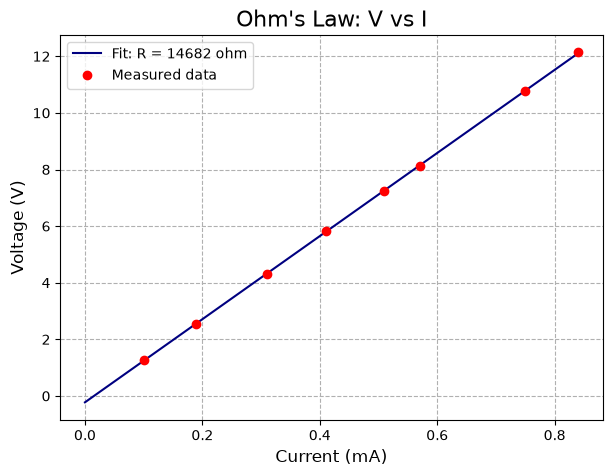

In [12]:
# Linear regression: V = I*R  ->  slope = R
fit = linregress(I_measured, V_measured)
R_fit = fit.slope

print(f"Measured R (from fit slope): {R_fit:.1f} Ω")
print(f"Nominal R: {R_nominal:.0f} Ω")
print(f"Difference: {abs(R_fit - R_nominal) / R_nominal * 100:.2f}%")

fig, ax = plt.subplots(figsize=(7, 5))
I_fit_line = np.linspace(0, I_measured.max(), 50) if len(I_measured) else np.array([0, 1])
ax.plot(I_fit_line * 1000, fit.slope * I_fit_line + fit.intercept, '-', label=f'Fit: R = {R_fit:.0f} ohm', color="navy")
ax.plot(I_measured * 1000, V_measured, 'o', label='Measured data', color="red")

look_nice(ax, "Current (mA)", "Voltage (V)", "Ohm's Law: V vs I")
plt.show()

### Final Observations
- The relation is linear, confirming that Ohm's law is valid.

## 1L.3   Voltage divider

### Textbook questions
- No questions found in the textbook, rather general lab advice.

### Lecture questions
1. When doing this experiment, should you use the nominal or measured values of the resistance? Why?
   - I chose to use the measured values of resistance, primarily because it was simple enough to test each resistor and faster when searching for specific resistance values. At times it may be best to use the nominal values, as Professor Eno has put less emphasis on error analysis and more on practical lab skills.

2. Discuss the text at the top of page 30 (shown below) with your instructor before wiring it.
   - Done with Professor Eno.

### Instructions
1. Construct the voltage divider (Circuit 2): R1 = 15k, R2 = 15k, $V_{in} = 15V$.
2. Measure the **open-circuit** output voltage → record as $V_{output}$.
   - Expected: $V_{output} = V_{in} \cdot \frac{R_2}{R_1+R_2} \approx 7.5\text{V}$
---
3. Attach the 7.5k load (Circuit 3) and observe/record the loaded output voltage.
4. Measure the **short-circuit current**: short the output to ground, routing the current *through the ammeter* (don't bypass it) → record as $I_{short\ circuit}$.
   - Expected: $I_{sc} = \frac{V_{in}}{R_1} \approx 1\text{mA}$
   - Check the DVM's ammeter current range before shorting — avoid tripping the internal fuse.
---
5. Calculate the Thevenin equivalent:
   - $R_{Thev} = \dfrac{V_{output}}{I_{short\ circuit}}$
   - Expected: $R_{Thev} \approx 7.5\text{k}\Omega$ (matches $R_1 \parallel R_2$)
---
6. Build the Thevenin equivalent circuit (7.5V source + 7.5kΩ series resistor) and reattach the 7.5k load — confirm it reproduces the loaded output voltage from step 3.

### Circuit diagrams
<p align="left">
  <img src="lab1_circuit2.png" alt="Circuit 2 Diagram" width="340" height="308"><br>
  <b>Circuit 2</b>
</p>
<p align="left">
  <img src="lab1_circuit3.png" alt="Circuit 3 Diagram" width="340" height="308"><br>
  <b>Circuit 3</b>
</p>

In [13]:
Vin = 14.9            # V
R1 = 14.91 * k
R2 = 14.56 * k
Rload = 7.55 * k

# --- Expected open-circuit output (Circuit 2) ---
V_output_expected = Vin * R2 / (R1 + R2)
print(f"Expected V_output (open circuit): {V_output_expected:.2f} V")

# --- Expected loaded output (Circuit 3) ---
R2_parallel_load = (R2 * Rload) / (R2 + Rload)
V_output_loaded_expected = Vin * R2_parallel_load / (R1 + R2_parallel_load)
print(f"Expected V_output (with 7.5k load): {V_output_loaded_expected:.2f} V")

# --- Expected short-circuit current ---
I_sc_expected = Vin / R1
print(f"Expected I_short_circuit: {I_sc_expected * 1000:.2f} mA")

# --- Expected Thevenin equivalent ---
R_Thev_expected = (R1 * R2) / (R1 + R2)
print(f"Expected R_Thev: {R_Thev_expected:.0f} ohm")

Expected V_output (open circuit): 7.36 V
Expected V_output (with 7.5k load): 3.73 V
Expected I_short_circuit: 1.00 mA
Expected R_Thev: 7366 ohm


In [14]:
V_output = 7.44                 # measured open-circuit output voltage, V
V_output_loaded = 3.773         # measured output voltage with 7.5k load attached, V
I_short_circuit = 0.51e-3       # measured short-circuit current (through ammeter), A

In [15]:
R_Thev = V_output / I_short_circuit
V_Thev = V_output   # open-circuit voltage IS the Thevenin voltage

print(f"Calculated R_Thev: {R_Thev:.0f} ohm  (expected ≈ {R_Thev_expected:.0f} ohm)")
print(f"Calculated V_Thev: {V_Thev:.2f} V")

Calculated R_Thev: 14588 ohm  (expected ≈ 7366 ohm)
Calculated V_Thev: 7.44 V


In [16]:
# Predict the loaded output using the Thevenin equivalent
V_load_from_Thev = V_Thev * Rload / (R_Thev + Rload)

# Measured values from the built Thevenin-equivalent circuit
V_Thev_meas = 3.722    # V
I_load_meas = 0.52     # mA

diff = V_load_from_Thev - V_Thev_meas

print(f"Measured loaded V_out from Thevenin circuit: {V_Thev_meas:.2f} V")
print(f"Predicted loaded V_out from Thevenin model: {V_load_from_Thev:.2f} V")
print(f"Difference: {diff:.3f} V")
print(f"Current through the load: {I_load_meas:.3f} mA")

print()
print(f"Voltage divider output voltage: {V_output_loaded} V")
print(f"Voltage divider short-circuit current: {I_short_circuit * 1000:.2f} mA")

Measured loaded V_out from Thevenin circuit: 3.72 V
Predicted loaded V_out from Thevenin model: 2.54 V
Difference: -1.185 V
Current through the load: 0.520 mA

Voltage divider output voltage: 3.773 V
Voltage divider short-circuit current: 0.51 mA
